# Raw Returns Backtest — Model Comparison

## 1. Setup & Config

In [64]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd


warnings.filterwarnings("ignore")

PROJECT_DIR = Path("/home/ra_yeye/2026_projects/nautilus_trader")
sys.path.insert(0, str(PROJECT_DIR))

from my_strategies.utils.plots import calculate_portfolio_performance
from my_strategies.utils.plots import plot_cum_returns
from my_strategies.utils.plots import plot_drawdown_chart
from my_strategies.utils.plots import pretty_print
from my_strategies.utils.plots import print_portfolio_performance


In [65]:
DATA_DIR = PROJECT_DIR / "my_strategies" / "data"
OHLCV_DIR = DATA_DIR / "binance_1m_perps_20241201_20260213"

SIGNAL_PATHS = {
    "Jenny_v6": DATA_DIR / "signals" / "signals_2024-12-01_2026-02-21_20260221_125721.parquet",
    "Maicro_v2": DATA_DIR / "signals" / "signals_v2_2024-12-01_2026-03-01_20260301_090129.parquet",
    "Maicro_v2_dow7": DATA_DIR
    / "signals"
    / "signals_v2_dow7_2024-12-01_2026-03-01_20260301_083431.parquet",
}

REBALANCE_HOUR = 0
SIGNAL_OFFSET_DAYS = 1

# Force all models to end at the same date for fair comparison
from datetime import date

END_DATE = date(2026, 2, 21)

## 2. Load Prices & Compute Daily Returns

In [53]:
# Collect all symbols across all signal files
all_symbols = set()
for path in SIGNAL_PATHS.values():
    df = pd.read_parquet(path, columns=["symbol"])
    all_symbols |= set(df["symbol"].unique())

# Load open price at rebalance hour for each symbol that has OHLCV data
daily_opens = {}
for symbol in sorted(all_symbols):
    filepath = OHLCV_DIR / f"{symbol}USDT.parquet"
    if not filepath.exists():
        continue
    ohlcv = pd.read_parquet(filepath, columns=["timestamp", "open"])
    ohlcv["timestamp"] = pd.to_datetime(ohlcv["timestamp"], utc=True)
    # Filter to rebalance hour, minute=0
    mask = (ohlcv["timestamp"].dt.hour == REBALANCE_HOUR) & (ohlcv["timestamp"].dt.minute == 0)
    daily = ohlcv.loc[mask, ["timestamp", "open"]].copy()
    daily["date"] = daily["timestamp"].dt.date
    daily_opens[symbol] = daily.set_index("date")["open"]

# Build price matrix and compute returns
prices_df = pd.DataFrame(daily_opens)
returns_df = prices_df.pct_change().iloc[1:]  # drop first NaN row

print(f"Symbols with data: {len(daily_opens)}")
print(f"Date range: {returns_df.index.min()} to {returns_df.index.max()}")
print(f"Trading days: {len(returns_df)}")
returns_df.head()

Symbols with data: 122
Date range: 2024-12-02 to 2026-02-24
Trading days: 450


,0G,AAVE,ADA,AIXBT,ALGO,ALT,ANIME,APT,AR,ARB,...,WIF,WLD,WLFI,XLM,XPL,XRP,YGG,ZEN,ZK,ZRO
date,,,,,,,,,,,,,,,,,,,,,
2024-12-02,NaN,-0.012075,0.066031,NaN,0.095946,0.081688,NaN,0.005135,-0.019658,-0.002058,...,0.081434,-0.061441,NaN,0.069485,NaN,0.174766,-0.009328,0.082793,0.137871,0.277978
2024-12-03,NaN,0.125048,0.045609,NaN,0.036991,-0.016378,NaN,0.020162,0.025135,0.059485,...,-0.092426,-0.035608,NaN,-0.038797,NaN,0.187429,0.040997,-0.002882,0.051307,-0.000523
2024-12-04,NaN,0.021092,-0.009222,NaN,0.004360,0.111186,NaN,0.057441,0.085448,0.017612,...,0.050967,0.004231,NaN,-0.060795,NaN,-0.077637,0.064709,-0.029755,-0.008625,-0.030131
2024-12-05,NaN,0.066168,-0.003606,NaN,-0.055446,0.047949,NaN,-0.026303,-0.037041,0.087015,...,-0.026122,0.000424,NaN,-0.034317,NaN,-0.060811,0.053065,-0.037269,0.000755,0.020204
2024-12-06,NaN,-0.033721,-0.023313,NaN,-0.059954,-0.006196,NaN,-0.035561,-0.003446,-0.030084,...,0.047887,0.127617,NaN,-0.037171,NaN,-0.048519,0.003103,-0.003701,0.013174,0.012861


## 3. Load Signals & Build Weight Matrices

In [54]:
def load_weight_matrix(signals_path: Path, signal_offset_days: int = 1) -> pd.DataFrame:

    df = pd.read_parquet(signals_path)
    df["date"] = pd.to_datetime(df["date"]).dt.date

    # Keep latest insert per (date, symbol)
    df = df.sort_values("inserted_at").drop_duplicates(subset=["date", "symbol"], keep="last")

    # Pivot to date x symbol
    weights = df.pivot(index="date", columns="symbol", values="weight").fillna(0.0)

    # Normalize: divide by gross exposure per day
    gross = weights.abs().sum(axis=1)
    weights = weights.div(gross, axis=0)

    # Align to return date: signal day S -> enter at open(S+offset) -> earn return at S+offset+1
    weights.index = pd.to_datetime(weights.index) + pd.Timedelta(days=signal_offset_days + 1)
    weights.index = weights.index.date
    weights.index.name = "date"

    return weights


# Only keep symbols that have OHLCV data
available_symbols = set(returns_df.columns)

weight_matrices = {}
for name, path in SIGNAL_PATHS.items():
    w = load_weight_matrix(path, SIGNAL_OFFSET_DAYS)
    # Check which symbols are dropped
    signal_symbols = set(w.columns)
    dropped = sorted(signal_symbols - available_symbols)
    if dropped:
        print(f"{name}: dropped {len(dropped)} symbols (no price data): {dropped}")
    # Filter to symbols with price data
    common_cols = sorted(signal_symbols & available_symbols)
    w = w[common_cols]
    weight_matrices[name] = w
    print(f"{name}: {w.shape[0]} days, {w.shape[1]} symbols")

weight_matrices["Jenny_v6"].head()

Jenny_v6: 448 days, 121 symbols
Maicro_v2: 455 days, 122 symbols
Maicro_v2_dow7: 454 days, 122 symbols


symbol,0G,AAVE,ADA,AIXBT,ALGO,ALT,ANIME,APT,AR,ARB,...,WIF,WLD,WLFI,XLM,XPL,XRP,YGG,ZEN,ZK,ZRO
date,,,,,,,,,,,,,,,,,,,,,
2024-12-03,0.0,0.0,-0.004055,0.0,0.000000,0.0,0.0,0.046903,0.0,0.003990,...,0.035781,-0.058939,0.0,-0.052823,0.0,-0.053019,0.0,0.0,0.0,0.0
2024-12-04,0.0,0.0,-0.045751,0.0,0.000000,0.0,0.0,0.013922,0.0,0.066648,...,-0.009023,-0.023291,0.0,-0.039469,0.0,-0.066648,0.0,0.0,0.0,0.0
2024-12-05,0.0,0.0,-0.025784,0.0,0.000000,0.0,0.0,0.055912,0.0,0.040366,...,0.034796,-0.003238,0.0,-0.043517,0.0,-0.042087,0.0,0.0,0.0,0.0
2024-12-06,0.0,0.0,0.020899,0.0,0.000000,0.0,0.0,0.049774,0.0,0.057431,...,0.057367,0.011359,0.0,-0.041798,0.0,-0.030948,0.0,0.0,0.0,0.0
2024-12-07,0.0,0.0,-0.001280,0.0,-0.020311,0.0,0.0,0.000000,0.0,0.027458,...,0.015747,-0.013917,0.0,-0.045006,0.0,-0.013512,0.0,0.0,0.0,0.0


## 4. Compute Portfolio Returns

In [55]:
portfolio_returns = {}
for name, weights in weight_matrices.items():
    # Align weights and returns on common dates and symbols
    common_dates = sorted(set(weights.index) & set(returns_df.index))
    common_syms = sorted(set(weights.columns) & set(returns_df.columns))
    w = weights.loc[common_dates, common_syms]
    r = returns_df.loc[common_dates, common_syms]
    # weight[T] * return[T]: both indexed by return date
    portfolio_returns[name] = (w * r).sum(axis=1)
    print(f"{name}: {len(common_dates)} days, {len(common_syms)} symbols")

# Merge into a single DataFrame for plotting
portfolio_df = pd.DataFrame(portfolio_returns)
portfolio_df.index.name = "date"
portfolio_df = portfolio_df.reset_index()
portfolio_df["date"] = pd.to_datetime(portfolio_df["date"])

# Truncate to END_DATE
portfolio_df = portfolio_df[portfolio_df["date"].dt.date <= END_DATE]
print(f"\nTruncated to END_DATE={END_DATE}: {len(portfolio_df)} days")
portfolio_df.head()

Jenny_v6: 448 days, 121 symbols
Maicro_v2: 449 days, 122 symbols
Maicro_v2_dow7: 449 days, 122 symbols

Truncated to END_DATE=2026-02-21: 446 days


,date,Jenny_v6,Maicro_v2,Maicro_v2_dow7
0,2024-12-03,-0.003768,-0.012105,-0.026413
1,2024-12-04,0.061365,0.063528,0.061318
2,2024-12-05,0.003781,-0.001587,0.006782
3,2024-12-06,0.001557,-0.007657,-0.002550
4,2024-12-07,-0.003278,-0.008468,-0.008362


## 5. Compute Turnover

In [56]:
turnover = {}
for name, weights in weight_matrices.items():
    daily_to = weights.diff().abs().sum(axis=1)
    daily_to.iloc[0] = weights.iloc[0].abs().sum()  # first day: full portfolio build
    turnover[name] = daily_to

turnover_df = pd.DataFrame(turnover)
turnover_df.index.name = "date"

# Truncate to END_DATE
turnover_df = turnover_df[turnover_df.index <= END_DATE]

for name in turnover_df.columns:
    print(f"{name} — mean daily turnover: {turnover_df[name].mean():.4f}")

turnover_df.head()

Jenny_v6 — mean daily turnover: 0.9137
Maicro_v2 — mean daily turnover: 0.9044
Maicro_v2_dow7 — mean daily turnover: 0.9078


,Jenny_v6,Maicro_v2,Maicro_v2_dow7
date,,,
2024-12-03,1.000000,1.000000,1.000000
2024-12-04,1.098385,0.763844,0.735138
2024-12-05,0.962319,0.959405,1.032266
2024-12-06,0.986900,1.035299,0.894677
2024-12-07,0.908606,0.813463,0.825846


## 6. Performance Summary

In [57]:
# Per-model performance
for name in SIGNAL_PATHS:
    print(f"\n{name}:")
    print_portfolio_performance(portfolio_df, date_col="date", ret_col=name, freq="D")


Jenny_v6:
╭────────────────┬─────────┬────────────────┬────────────────┬───────────────┬───────────────────╮
│ Total Return   │ CAGR    │   Sharpe Ratio │ Max Drawdown   │ Ann. Return   │ Ann. Volatility   │
├────────────────┼─────────┼────────────────┼────────────────┼───────────────┼───────────────────┤
│ 198.11%        │ 145.11% │           3.54 │ -10.99%        │ 92.94%        │ 26.24%            │
╰────────────────┴─────────┴────────────────┴────────────────┴───────────────┴───────────────────╯

Maicro_v2:
╭────────────────┬─────────┬────────────────┬────────────────┬───────────────┬───────────────────╮
│ Total Return   │ CAGR    │   Sharpe Ratio │ Max Drawdown   │ Ann. Return   │ Ann. Volatility   │
├────────────────┼─────────┼────────────────┼────────────────┼───────────────┼───────────────────┤
│ 154.12%        │ 115.00% │            2.9 │ -11.55%        │ 80.20%        │ 27.64%            │
╰────────────────┴─────────┴────────────────┴────────────────┴───────────────┴────────

## 7. Plots

### Cumulative Returns

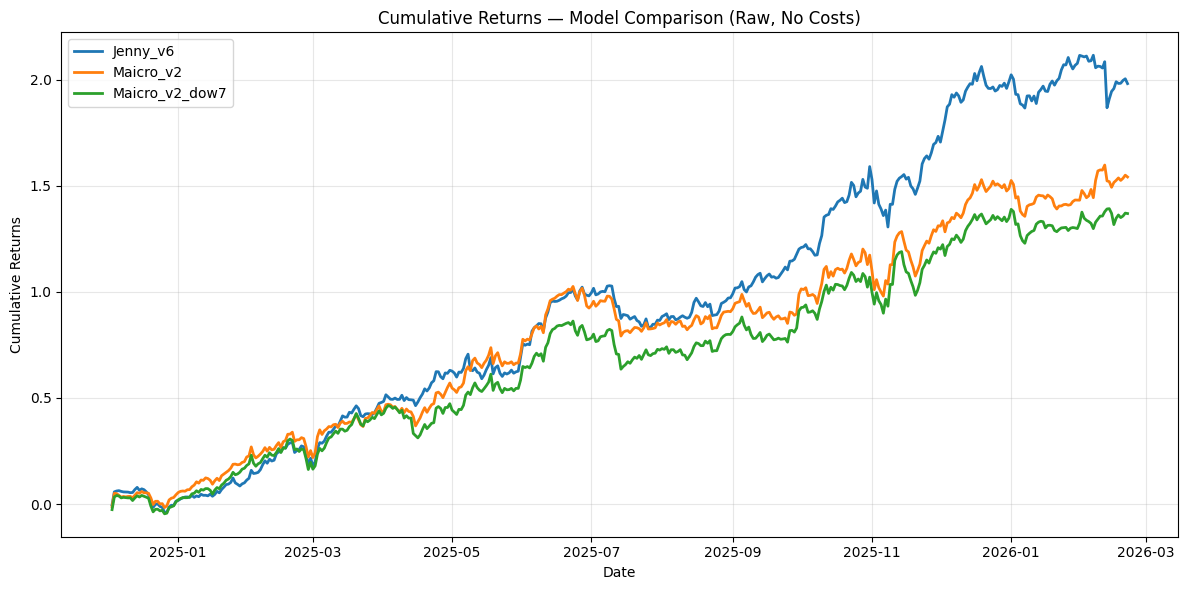

In [58]:
model_names = list(SIGNAL_PATHS.keys())
plot_cum_returns(
    portfolio_df,
    index_col_name="date",
    ret_col_lst=model_names,
    title="Cumulative Returns — Model Comparison (Raw, No Costs)",
)

### Drawdown


Jenny_v6:


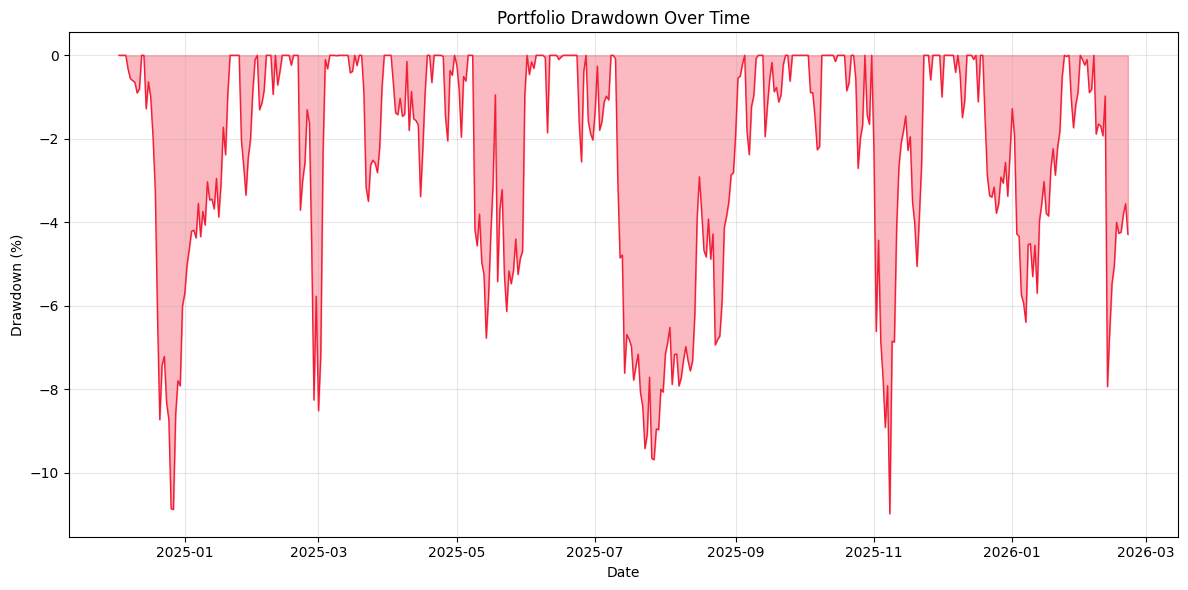


Maicro_v2:


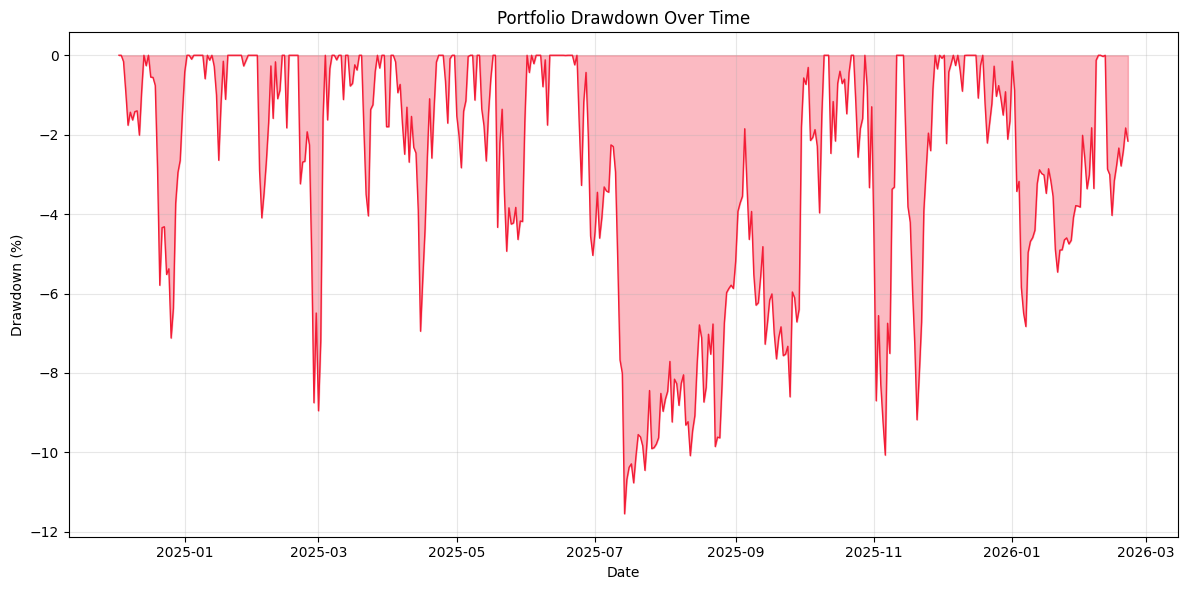


Maicro_v2_dow7:


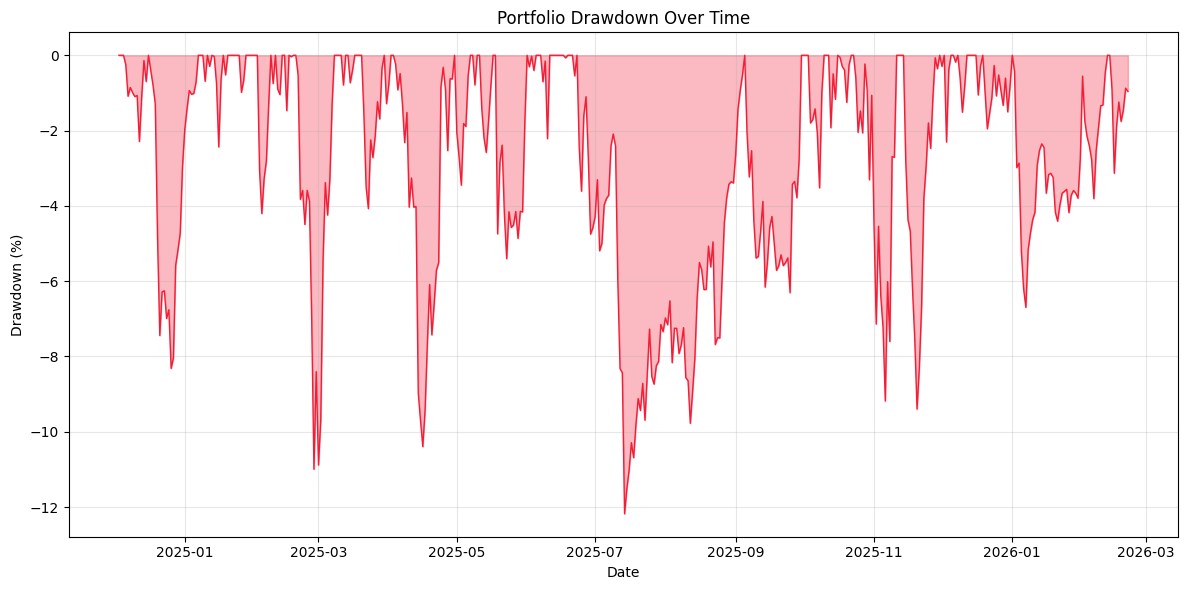

In [59]:
for name in model_names:
    print(f"\n{name}:")
    plot_drawdown_chart(portfolio_df, date_col="date", ret_col=name)

### Cumulative Turnover

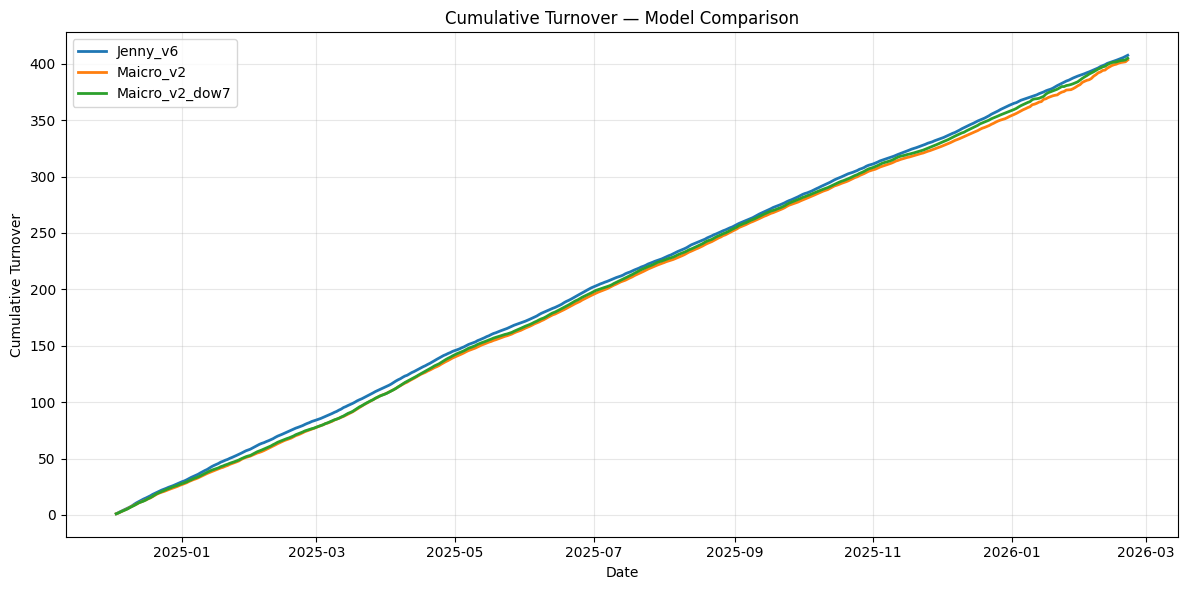

In [60]:
import matplotlib.pyplot as plt
from my_strategies.utils.plots import DEFAULT_FIGSIZE

plt.figure(figsize=DEFAULT_FIGSIZE)
for name in model_names:
    cum_to = turnover_df[name].cumsum()
    plt.plot(turnover_df.index, cum_to, label=name, linewidth=2)

plt.xlabel("Date")
plt.ylabel("Cumulative Turnover")
plt.title("Cumulative Turnover — Model Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Cost-Adjusted Returns

In [61]:
TAKER_FEE_BPS = 4.5
SLIPPAGE_BPS = 5.0
TOTAL_COST_BPS = TAKER_FEE_BPS + SLIPPAGE_BPS

# Align turnover_df dates with portfolio_df dates
turnover_aligned = turnover_df.loc[portfolio_df["date"].dt.date.values]

# net_return = gross_return - turnover * cost
portfolio_net_df = portfolio_df.copy()
for name in model_names:
    portfolio_net_df[name] = (
        portfolio_df[name].values - turnover_aligned[name].values * TOTAL_COST_BPS / 10_000
    )

print(f"Total cost: {TOTAL_COST_BPS} bps (taker fee: {TAKER_FEE_BPS} + slippage: {SLIPPAGE_BPS})")
portfolio_net_df.head()

Total cost: 9.5 bps (taker fee: 4.5 + slippage: 5.0)


,date,Jenny_v6,Maicro_v2,Maicro_v2_dow7
0,2024-12-03,-0.004718,-0.013055,-0.027363
1,2024-12-04,0.060321,0.062802,0.060620
2,2024-12-05,0.002867,-0.002498,0.005801
3,2024-12-06,0.000620,-0.008641,-0.003400
4,2024-12-07,-0.004142,-0.009241,-0.009146


In [62]:
# Side-by-side: gross vs net
rows = []
for name in model_names:
    g = calculate_portfolio_performance(portfolio_df, "date", name, "D")
    n = calculate_portfolio_performance(portfolio_net_df, "date", name, "D")
    rows.append(
        {
            "Model": name,
            "Gross Return": f"{g['total_return'] * 100:.2f}%",
            "Net Return": f"{n['total_return'] * 100:.2f}%",
            "Gross Sharpe": f"{g['sharpe_ratio']:.2f}",
            "Net Sharpe": f"{n['sharpe_ratio']:.2f}",
            "Max DD (Net)": f"{n['max_drawdown'] * 100:.2f}%",
            "Mean Daily TO": f"{turnover_df[name].mean():.4f}",
        }
    )

pretty_print(pd.DataFrame(rows))

╭────────────────┬────────────────┬──────────────┬────────────────┬──────────────┬────────────────┬─────────────────╮
│ Model          │ Gross Return   │ Net Return   │   Gross Sharpe │   Net Sharpe │ Max DD (Net)   │   Mean Daily TO │
├────────────────┼────────────────┼──────────────┼────────────────┼──────────────┼────────────────┼─────────────────┤
│ Jenny_v6       │ 198.11%        │ 102.57%      │           3.54 │         2.33 │ -11.92%        │          0.9137 │
├────────────────┼────────────────┼──────────────┼────────────────┼──────────────┼────────────────┼─────────────────┤
│ Maicro_v2      │ 154.12%        │ 73.33%       │           2.9  │         1.77 │ -15.87%        │          0.9044 │
├────────────────┼────────────────┼──────────────┼────────────────┼──────────────┼────────────────┼─────────────────┤
│ Maicro_v2_dow7 │ 136.88%        │ 61.33%       │           2.67 │         1.54 │ -13.79%        │          0.9078 │
╰────────────────┴────────────────┴──────────────┴──────

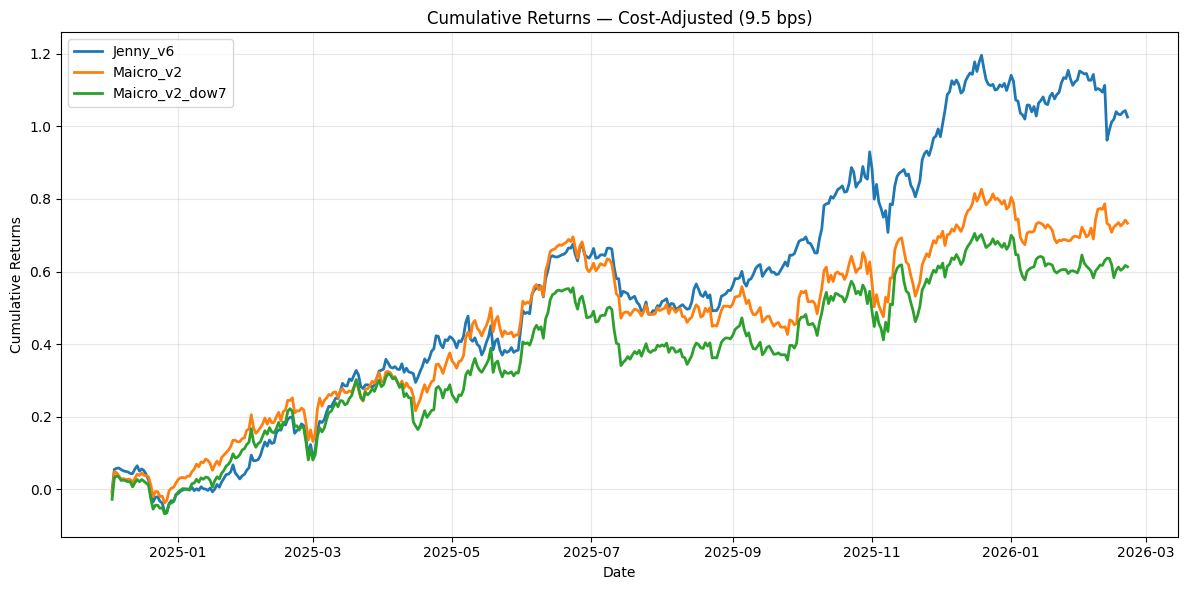

In [63]:
plot_cum_returns(
    portfolio_net_df,
    index_col_name="date",
    ret_col_lst=model_names,
    title=f"Cumulative Returns — Cost-Adjusted ({TOTAL_COST_BPS:.1f} bps)",
)